<a href="https://colab.research.google.com/github/NagaRaju1991/google_colab_notebooks/blob/fsds_course/03_Pytorch_Basics_MLP_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

## Key PyTorch Classes and Functions Used

| Class / Function | Purpose |
|------------------|---------|
| `torch.nn.Module` | Base class for all neural network modules. Your custom model must inherit from it. |
| `torch.nn.Linear` | Applies a linear (fully connected) transformation to the incoming data: `y = xA^T + b`. |
| `torch.nn.ReLU` | Applies the rectified linear unit activation function element-wise. |
| `torch.nn.Sequential` | A container that sequentially chains layers; the forward pass propagates input through each layer in order. |
| `torch.nn.MSELoss` | Mean squared error loss, commonly used for regression tasks. |
| `torch.optim.Adam` | Implements the Adam optimizer, a popular gradient‑based optimization algorithm. |
| `torch.utils.data.TensorDataset` | Wraps input and target tensors into a Dataset object. |
| `torch.utils.data.DataLoader` | Combines a dataset with a sampler, providing iterable batches, shuffling, and multi‑process loading. |
| `model.to(device)` | Moves model parameters and buffers to the specified device (CPU or GPU). |
| `optimizer.zero_grad()` | Clears the gradients of all optimized tensors. Needed because PyTorch accumulates gradients by default. |
| `loss.backward()` | Computes the gradient of the loss with respect to all tensors that have `requires_grad=True`. |
| `optimizer.step()` | Performs a parameter update based on the current gradients. |
| `model.train()` / `model.eval()` | Sets the model to training or evaluation mode, affecting layers like dropout and batch normalization. |
| `torch.no_grad()` | Context manager that disables gradient tracking, useful for inference to reduce memory consumption. |

### Pytorch use-case steps :
- Import PyTorch and helper libraries

- Load and prepare the dataset (split, scale, convert to tensors)

- Create DataLoaders for batching

- Define the model using nn.Sequential

- Choose loss function and optimizer

- Move model to device (GPU if available)

- Train the model (loop over epochs and batches)

- Evaluate the model on test data

### Regression on California Housing Dataset

In [ ]:
import torch
import torch.nn as nn

# Create a linear layer: input_dim=10, output_dim=5
layer = nn.Linear(in_features=10, out_features=5)

# Parameters
print(f"Weight shape: {layer.weight.shape}")  # [5, 10]
print(f"Bias shape: {layer.bias.shape}")      # [5]
print(f"Total parameters: {10*5 + 5}")

Weight shape: torch.Size([5, 10])
Bias shape: torch.Size([5])
Total parameters: 55


In [ ]:
# Common activation functions
relu = nn.ReLU()        # f(x) = max(0, x)
sigmoid = nn.Sigmoid()   # f(x) = 1/(1+e^(-x))
tanh = nn.Tanh()        # f(x) = (e^x - e^(-x))/(e^x + e^(-x))

# Apply activation
x = torch.randn(2, 5)
output = relu(x)        # Negative values become 0
print(output)

tensor([[1.4827, 1.5913, 0.7003, 0.0000, 1.1225],
        [0.0000, 0.0000, 1.0333, 0.0000, 0.6734]])


| Layer # | Type   | Neurons | Counts As Layer? | Purpose            |
| ------- | ------ | ------- | ---------------- | ------------------ |
| 1       | Linear | 784→128 | ✅ HIDDEN LAYER   | Feature extraction |
| 2       | Linear | 128→64  | ✅ HIDDEN LAYER   | Pattern learning   |
| 3       | Linear | 64→10   | ✅ OUTPUT LAYER   | Final prediction   |

In [ ]:
model = nn.Sequential(
    nn.Linear(784, 128),    # 🟢 LAYER 1: Input → Hidden1 (784→128 neurons)
    nn.ReLU(),              # ⚪ Activation (NOT a layer)
    nn.Linear(128, 64),     # 🟢 LAYER 2: Hidden1 → Hidden2 (128→64 neurons)
    nn.ReLU(),              # ⚪ Activation (NOT a layer)
    nn.Linear(64, 10)       # 🟢 LAYER 3: Hidden2 → Output (64→10 neurons)
)


In [ ]:

# Forward pass
input_data = torch.randn(784)
output = model(input_data)

**Step 1**

In [ ]:
# 1. IMPORTS
# PyTorch core libraries
import torch
import torch.nn as nn                 # neural network modules (layers, loss functions)
import torch.optim as optim           # optimizers (SGD, Adam, etc.)
from torch.utils.data import DataLoader, TensorDataset   # data handling utilities

# Scikit-learn for dataset, splitting, and scaling
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**Step 2**

In [ ]:
# 2. LOAD AND PREPARE DATA
# Fetch the California Housing dataset (returns a dictionary-like object)
housing = fetch_california_housing()
# Features: 8 numerical columns; target: median house value
X, y = housing.data, housing.target

# Split into training (80%) and testing (20%) sets
# random_state ensures reproducible splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling: Neural networks train better when inputs are normalized (mean=0, std=1)
scaler = StandardScaler()
# Fit the scaler on training data only, then transform both train and test
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert NumPy arrays to PyTorch tensors
# dtype=torch.float32 is required for most PyTorch operations (default float)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Reshape target tensors to have shape (n_samples, 1) – needed for MSELoss which expects
# predictions and targets to have the same dimensions.
# view(-1, 1) keeps the first dimension (number of samples) and adds a second dimension of size 1.
y_train = y_train.view(-1, 1)
y_test = y_test.view(-1, 1)

**Step 3**

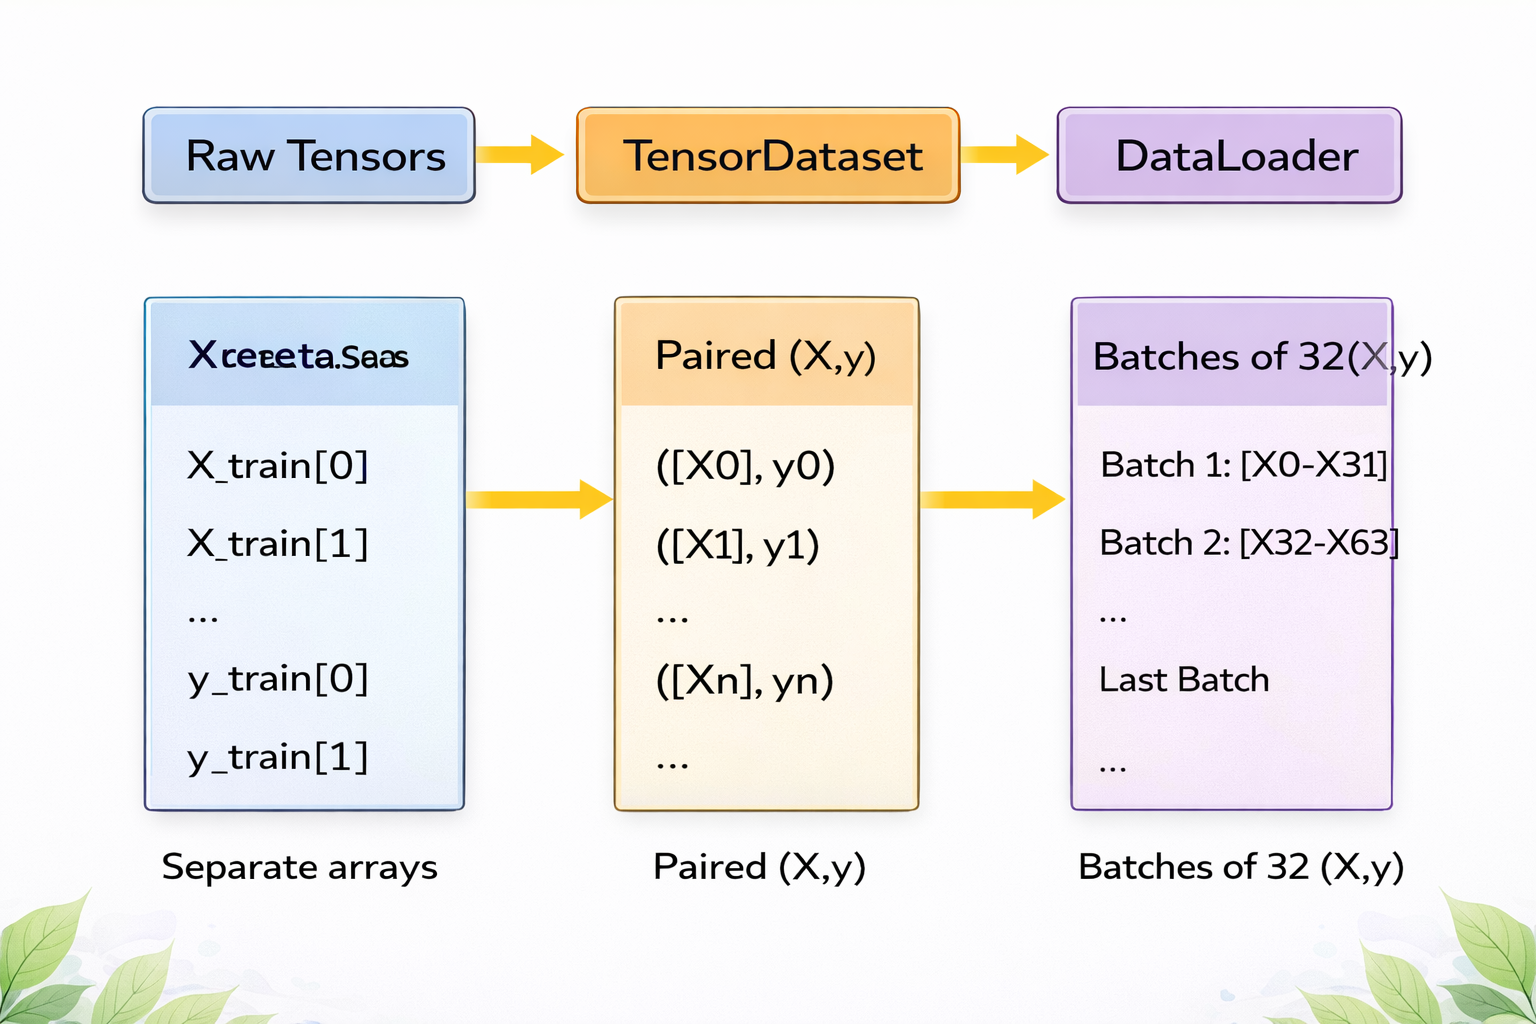

In [ ]:
# 3. CREATE DATALOADERS
# TensorDataset wraps input and target tensors into a Dataset object that DataLoader can use.
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader provides batches, shuffling, and parallel data loading.
# batch_size=32: each iteration returns 32 samples.
# shuffle=True for training to avoid learning order-dependent patterns.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# For testing, we usually don't shuffle; we just iterate over all samples in order.
test_loader = DataLoader(test_dataset, batch_size=32)

**Step 4**

In [ ]:
# 4. DEFINE THE MODEL USING nn.Sequential
# nn.Sequential is a container that stacks layers in the order they are passed.
# The forward pass automatically applies them sequentially.
model = nn.Sequential(
    # First hidden layer: Linear(input_features=8, output_features=64)
    # nn.Linear applies a linear transformation: y = xW^T + b
    nn.Linear(8, 64),
    # Activation function: ReLU (Rectified Linear Unit) introduces non-linearity.
    # It outputs max(0, input). Without non-linear activations, the whole network would be a linear model.
    nn.ReLU(),
    # Second hidden layer: from 64 to 32 neurons
    nn.Linear(64, 32),
    nn.ReLU(),
    # Output layer: from 32 to 1 neuron.
    # No activation here because regression typically outputs raw values.
    nn.Linear(32, 1)
)

**Step 5**

In [ ]:
# 5. LOSS FUNCTION AND OPTIMIZER
# For regression, Mean Squared Error (MSE) is a common loss.
# It measures the average squared difference between predictions and targets.
criterion = nn.MSELoss()

# Optimizer: Adam (Adaptive Moment Estimation) is a popular gradient‑based optimization algorithm.
# It adapts the learning rate for each parameter and works well out‑of‑the‑box.
# model.parameters() provides all trainable weights of the model.
optimizer = optim.Adam(model.parameters(), lr=0.001)   # lr = learning rate

**Step 6**

In [ ]:
# 6. MOVE MODEL TO DEVICE (GPU IF AVAILABLE)
# Check if CUDA (GPU support) is available; otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move all model parameters and buffers to the selected device.
model.to(device)


Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

**Step 7**

In [ ]:
# 7. TRAINING LOOP
num_epochs = 20   # Number of complete passes through the training data

for epoch in range(num_epochs):
    # Set model to training mode (enables dropout, batch norm updates if used – not needed here but good practice)
    model.train()
    total_loss = 0.0

    # Iterate over batches from the training DataLoader
    for X_batch, y_batch in train_loader:
        # Move batch data to the same device as the model
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Zero the gradients from the previous step.
        # By default, PyTorch accumulates gradients; we need to clear them before each backward pass.
        optimizer.zero_grad()

        # Forward pass: compute predictions for the batch
        pred = model(X_batch)

        # Compute loss between predictions and true targets
        loss = criterion(pred, y_batch)

        # Backward pass: compute gradients of the loss w.r.t. all model parameters
        loss.backward()

        # Update model parameters using the computed gradients
        optimizer.step()

        # Accumulate loss for monitoring (multiply by batch size to get sum, then divide later)
        total_loss += loss.item() * X_batch.size(0)

    # Calculate average loss over the entire training set
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 1.0584
Epoch 2, Loss: 0.4397
Epoch 3, Loss: 0.4026
Epoch 4, Loss: 0.3814
Epoch 5, Loss: 0.3729
Epoch 6, Loss: 0.3726
Epoch 7, Loss: 0.3542
Epoch 8, Loss: 0.3441
Epoch 9, Loss: 0.3386
Epoch 10, Loss: 0.3705
Epoch 11, Loss: 0.3189
Epoch 12, Loss: 0.3115
Epoch 13, Loss: 0.3108
Epoch 14, Loss: 0.3068
Epoch 15, Loss: 0.3092
Epoch 16, Loss: 0.3051
Epoch 17, Loss: 0.3048
Epoch 18, Loss: 0.2987
Epoch 19, Loss: 0.3055
Epoch 20, Loss: 0.2946


**Step 8**

In [ ]:
# 8. EVALUATION ON TEST SET
# Set model to evaluation mode (disables dropout, uses running averages for batch norm if present)
model.eval()
# Disable gradient tracking for efficiency – we don't need gradients for evaluation
with torch.no_grad():
    # Get predictions for all test samples
    preds = model(X_test.to(device))
    # Compute test loss
    test_loss = criterion(preds, y_test.to(device))
    print(f"Test MSE: {test_loss.item():.4f}")

Test MSE: 0.3235


### Classification MNIST Digits dataset

**Step 1**

In [ ]:
# 1. IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms   # torchvision provides popular datasets and image transforms

**Step 2**

| Step        | What It Does                 | Before → After                    |
| ----------- | ---------------------------- | --------------------------------- |
| ToTensor()  | Raw image → PyTorch tensor   | [0-255] pixels → [0.0-1.0] tensor |
| Normalize() | Subtract mean, divide by std | [0,1] → [-1, 2] zero-centered     |

MNIST-specific values (pre-computed):
- Mean = 0.1307 (grayscale average)
- Std = 0.3081 (pixel variation)


In [ ]:
# 2. LOAD AND PREPARE DATA
# Define a sequence of transformations to apply to each image
transform = transforms.Compose([
    # Convert PIL image or numpy array to PyTorch tensor (values become [0,1])
    transforms.ToTensor(),
    # Normalize with mean and standard deviation of the MNIST dataset.
    # Normalization helps training stability. (mean, std) for each channel – here only one channel.
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training dataset
# root: directory to store data
# train=True: load training portion
# transform: apply the defined transformations
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.07MB/s]


In [ ]:
type(train_dataset)

torchvision.datasets.mnist.MNIST

| Problem                | Without DataLoader             | DataLoader Solution                         |
| ---------------------- | ------------------------------ | ------------------------------------------- |
| 1. Manual Batching     | Slice arrays manually          | batch_size=32 → auto 32-sample batches      |
| 2. Order Bias          | Model memorizes training order | shuffle=True → random order each epoch      |
| 3. Slow CPU Loading    | CPU blocks GPU                 | num_workers=4 → parallel data prep          |
| 4. Memory Overflow     | Load entire dataset            | Lazy loading → only current batch in memory |
| 5. No GPU Optimization | Slow CPU→GPU transfer          | pin_memory=True → fast GPU transfers        |

**Step 3**

In [ ]:
# 3. DATALOADERS
# batch_size=64: number of images per batch
# shuffle=True for training to randomize order
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


**Step 4**

In [ ]:
# 4. DEFINE MODEL USING nn.Sequential
model = nn.Sequential(
    # Flatten the input image: from shape (batch, 1, 28, 28) to (batch, 784)
    # nn.Flatten() is a convenient layer that does this without hard‑coding the dimension.
    nn.Flatten(),
    # First hidden layer: input 784 (28*28), output 128
    nn.Linear(28*28, 128),
    nn.ReLU(),
    # Second hidden layer: 128 -> 64
    nn.Linear(128, 64),
    nn.ReLU(),
    # Output layer: 64 -> 10 (one neuron per class, for digits 0‑9)
    # No softmax here because CrossEntropyLoss includes it internally.
    nn.Linear(64, 10)
)

**Step 5**

In [ ]:
# 5. LOSS FUNCTION AND OPTIMIZER
# For multi‑class classification, CrossEntropyLoss is standard.
# It combines LogSoftmax and Negative Log Likelihood Loss, expecting raw scores (logits) as input.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


**Step 6**

In [ ]:

# 6. DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)

**Step 7**

In [ ]:
# 7. TRAINING LOOP
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)               # forward pass, shape: (batch, 10)
        loss = criterion(outputs, labels)      # compute loss
        loss.backward()                         # backpropagation
        optimizer.step()                        # update weights

        # Track accuracy
        # torch.max returns (values, indices); we take the index of the highest logit as predicted class
        #outputs.shape = [32, 10]  # 32 samples, 10 classes (MNIST digits 0-9)

        #Sample 1 logits: [-1.2, 2.3, 0.1, -0.5, 1.8, 0.9, -2.1, 3.4, 0.2, -0.8]
        #                    ↑  ↑  ↑   ↑   ↑  ↑  ↑  ↑  ↑  ↑
        #                   [0] [1][2] [3] [4][5][6][7][8][9]

        #torch.max(outputs, 1) finds MAX along dim=1 (class axis):
        # Max value = 3.4, Index = 7 → Predict digit **7** ✓

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

Epoch 1, Loss: 0.2687, Accuracy: 91.92%
Epoch 2, Loss: 0.1119, Accuracy: 96.53%
Epoch 3, Loss: 0.0800, Accuracy: 97.46%
Epoch 4, Loss: 0.0604, Accuracy: 98.08%
Epoch 5, Loss: 0.0493, Accuracy: 98.45%


**Step 8**

In [ ]:
# 8. EVALUATION
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= len(test_loader.dataset)
test_acc = 100 * correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.0885, Test Accuracy: 97.35%


**TensorFlow**

In [ ]:
# 1. IMPORTS
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# 2. LOAD AND PREPARE DATA
# Keras provides built‑in datasets, including MNIST.
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Explore shapes: (60000, 28, 28) for training images, (60000,) for labels.
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Preprocessing:
# - Normalize pixel values from [0,255] to [0,1] (helps training).
# - Flatten the 28x28 images into vectors of length 784.
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0
X_train = X_train.reshape(-1, 784)   # -1 infers the batch size
X_test = X_test.reshape(-1, 784)

# Labels are integers 0‑9 – no need to one‑hot encode because we'll use sparse categorical crossentropy.

# 3. BUILD THE MODEL
model = keras.Sequential([
    # First hidden layer: 128 neurons, ReLU activation.
    # input_shape=(784,) specifies the flattened image size.
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # Second hidden layer: 64 neurons, ReLU.
    layers.Dense(64, activation='relu'),
    # Output layer: 10 neurons (one per class).
    # No softmax here because we'll use loss='sparse_categorical_crossentropy'
    # which internally applies softmax and computes cross‑entropy.
    layers.Dense(10)
])

# 4. COMPILE THE MODEL
# Optimizer: 'adam'
# Loss: 'sparse_categorical_crossentropy' – suitable when labels are integers (not one‑hot).
# Metrics: 'accuracy' – track classification accuracy.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. TRAIN THE MODEL
history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

# 6. EVALUATE ON TEST SET
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Optional: predictions (probabilities after softmax)
probs = tf.nn.softmax(model.predict(X_test[:5])).numpy()
predicted_classes = np.argmax(probs, axis=1)
print("Sample predicted classes:", predicted_classes)
print("True labels:", y_test[:5])

Train shape: (60000, 28, 28), Test shape: (10000, 28, 28)
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4441 - loss: 2.3936 - val_accuracy: 0.3858 - val_loss: 2.2316
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3588 - loss: 2.2538 - val_accuracy: 0.4150 - val_loss: 2.1365
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2204 - loss: 2.2522 - val_accuracy: 0.1453 - val_loss: 2.3026
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1488 - loss: 2.3026 - val_accuracy: 0.1453 - val_loss: 2.3026
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1495 - loss: 2.3026 - val_accuracy: 0.1453 - val_loss: 2.3026
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1454 - loss: 2.3026 - val_accuracy: 0.1453 - val_loss: 2.3026
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1504 - loss: 2.3026 - val_accuracy: 0.1453 - val_loss: 2.3026
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms